In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 13,
    'legend.fontsize': 11,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'mathtext.fontset': 'stix',
})

models = ['Decision\nTree', 'Random\nForest', 'XGBoost', 'LightGBM', 'CatBoost',
          'SVM', 'Logistic\nRegression', 'AutoML-\nEnsemble', 'LAE-XAI-\nIDS']

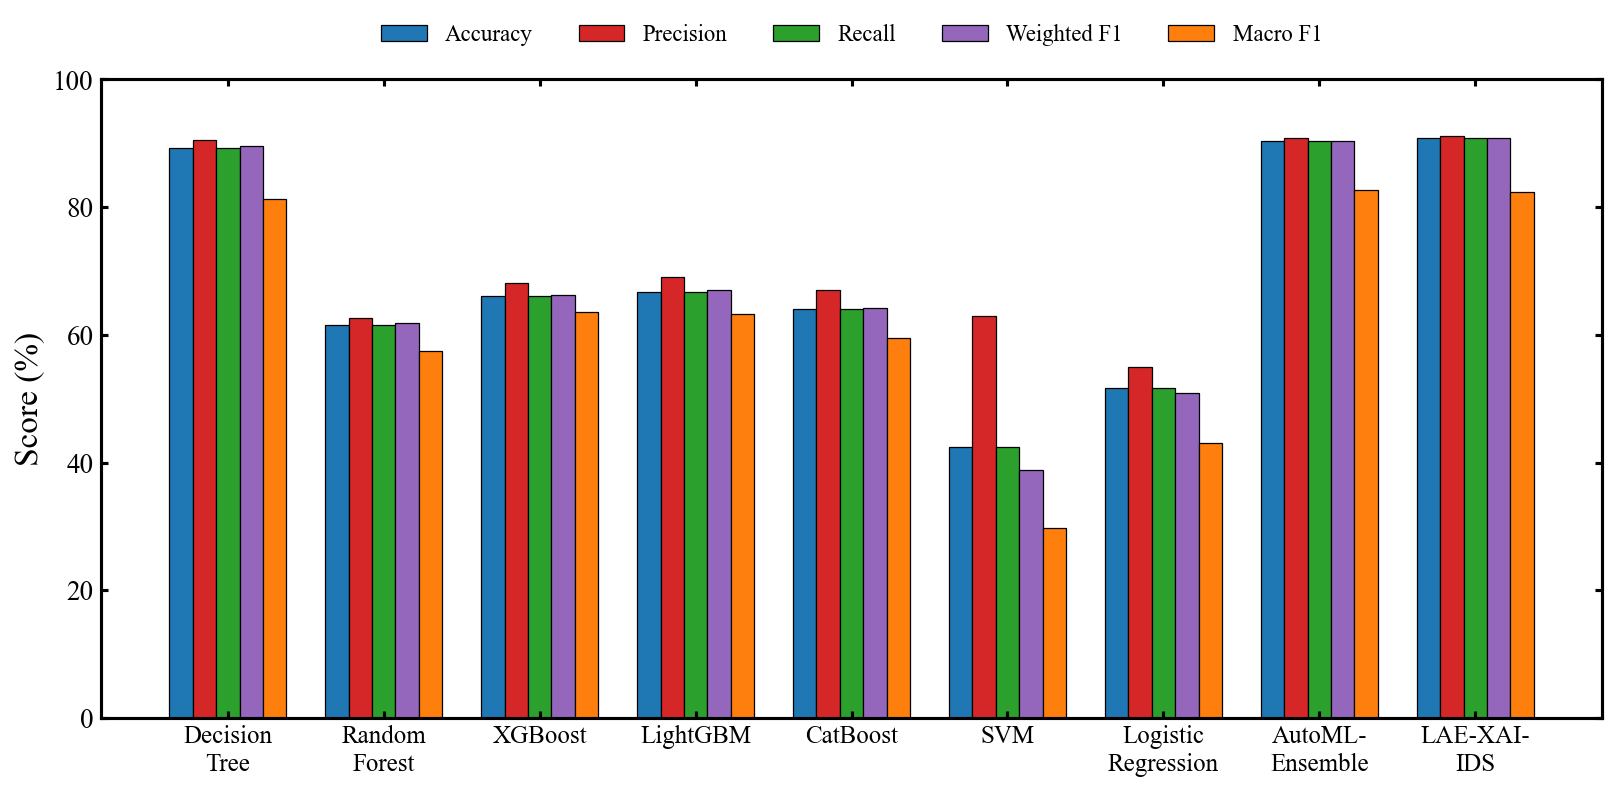

In [2]:
data = {
    'Accuracy':    [89.26265, 61.58378, 66.14883, 66.76316, 64.04184, 42.44035, 51.7049, 90.30877, 90.8025],
    'Precision':   [90.50933, 62.64816, 68.14386, 69.01002, 67.1052, 62.97954, 54.9438, 90.83621, 91.22521],
    'Recall':      [89.26265, 61.58378, 66.14883, 66.76316, 64.04184, 42.44035, 51.7049, 90.30877, 90.8025],
    'Weighted F1': [89.55065, 61.90089, 66.33237, 67.01061, 64.24811, 38.80214, 50.94426, 90.41276, 90.87478],
    'Macro F1':    [81.28163, 57.50149, 63.56469, 63.25238, 59.58697, 29.84018, 43.14038, 82.66188, 82.31669],
}
colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e']

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(models))
bar_width = 0.15
n = len(data)

for i, (metric, values) in enumerate(data.items()):
    offset = (i - (n - 1) / 2) * bar_width
    ax.bar(x + offset, values, width=bar_width, label=metric,
           color=colors[i], edgecolor='black', linewidth=0.6)

ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 100)
ax.tick_params(which='both', direction='in', top=True, right=True)
for spine in ax.spines.values(): spine.set_linewidth(1.5)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False)

plt.tight_layout()
plt.savefig('fig1_performance.png', bbox_inches='tight')
plt.show()

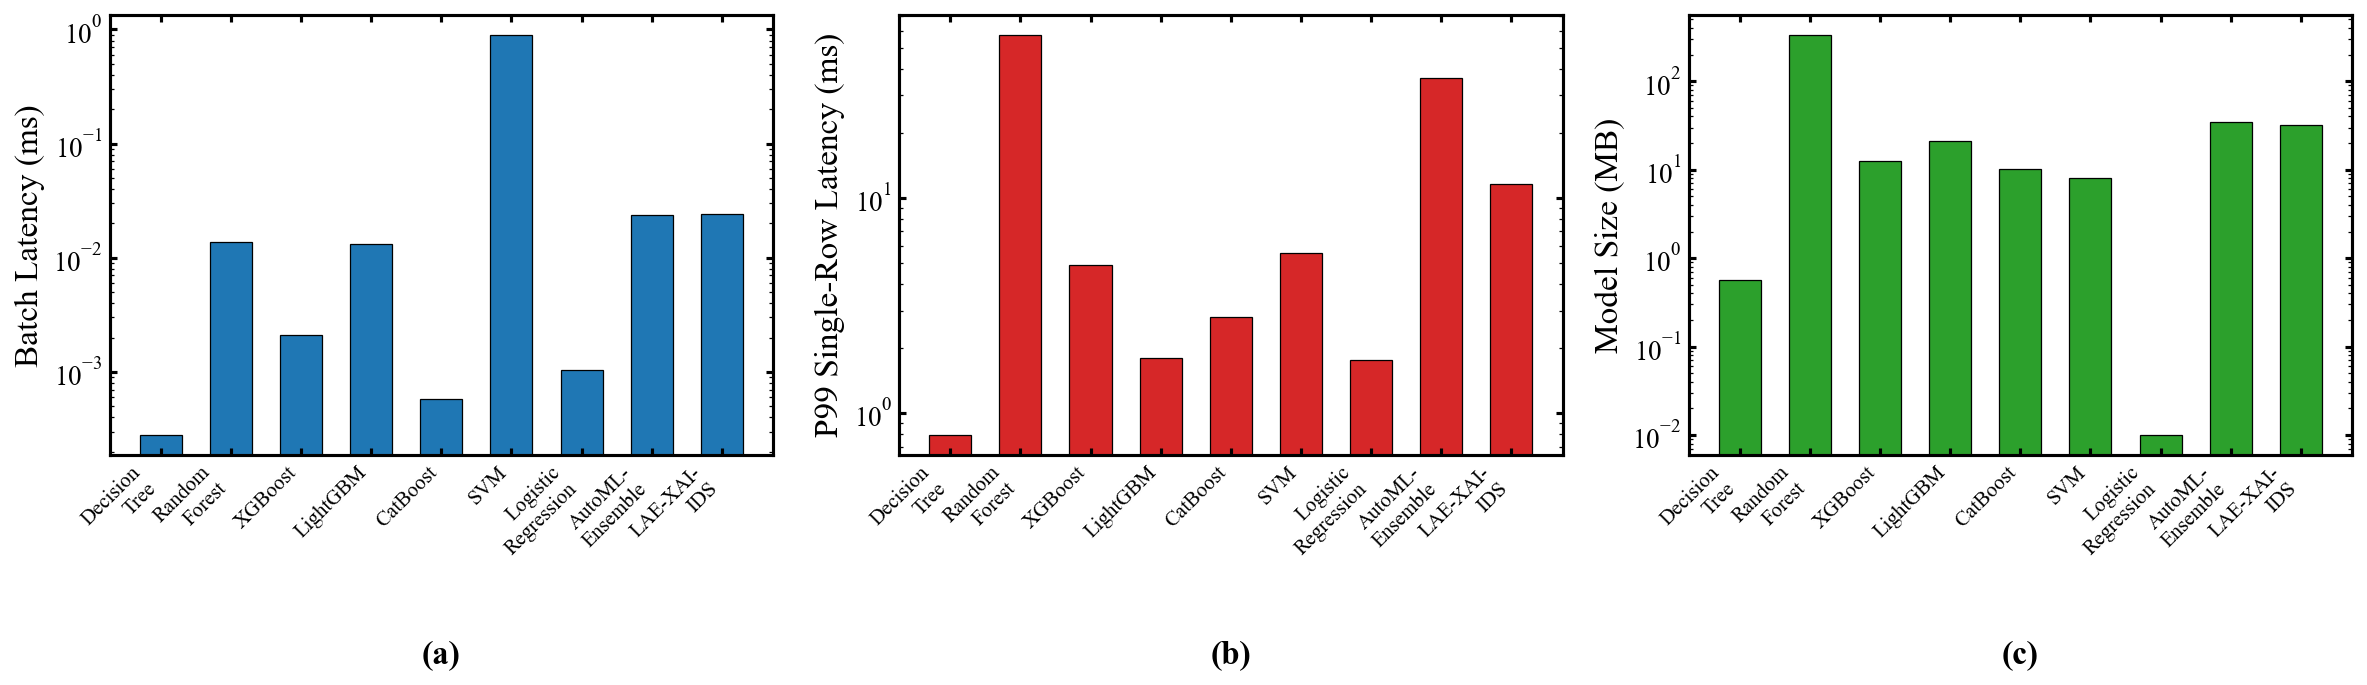

In [4]:
batch_latency = [0.00028, 0.013766, 0.002091, 0.013201, 0.000573, 0.901452, 0.001041, 0.023504, 0.0241]
p99_latency   = [0.792204, 57.57826, 4.905487, 1.812624, 2.79577, 5.581123, 1.775101, 36.10857, 11.59248]
model_size    = [0.566697, 337.4622, 12.67217, 21.32534, 10.19199, 8.071421, 0.009989, 34.56803, 31.74631]

panel_data = [('Batch Latency (ms)', batch_latency, '#1f77b4'),
              ('P99 Single-Row Latency (ms)', p99_latency, '#d62728'),
              ('Model Size (MB)', model_size, '#2ca02c')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
x = np.arange(len(models))

for ax, (ylabel, values, color) in zip(axes, panel_data):
    ax.bar(x, values, color=color, edgecolor='black', linewidth=0.6, width=0.6)
    ax.set_yscale('log')
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel(ylabel)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    for spine in ax.spines.values(): spine.set_linewidth(1.5)

for ax, lab in zip(axes, ['(a)', '(b)', '(c)']):
    ax.text(0.5, -0.42, lab, transform=ax.transAxes, ha='center', va='top',
            fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('fig2_efficiency.png', bbox_inches='tight')
plt.show()